In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/home/christian/bachelor-project


In [2]:
STATION_ID = 96

In [3]:
# BiLSTM training for 12-hour wind vector forecasting

# This notebook trains `BiLSTMModel` on 10-min measurements to forecast the next 12 hours (72 steps)
# of u/v vector components per station.

import os
from omegaconf import OmegaConf
from loguru import logger
import pandas as pd

from src.database.database_service import DatabaseService
from src.weather_stations.weather_station_service import WeatherStationService
from src.measurements.measurement_service import MeasurementService
from src.model.variant.bilstm_model import BiLSTMModel
from src.model.variant.patch_tst_model import PatchTSTModel

/home/christian/bachelor-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load config and initialize services
cfg = OmegaConf.load("conf/config.yaml")


In [5]:
measurements_df = pd.read_parquet("data/measurements.parquet")

In [6]:
# Filter for station_id = 96
station_id = STATION_ID
measurements_96 = measurements_df[measurements_df['station_id'] == station_id].copy()

# Ensure record_date is datetime
measurements_96['record_date'] = pd.to_datetime(measurements_96['record_date'])

# Find the last timestamp
last_time = measurements_96['record_date'].max()

# Get the last 36 hours of data
thirtysix_hours_ago = last_time - pd.Timedelta(hours=36)
df_36h = measurements_96[measurements_96['record_date'] >= thirtysix_hours_ago].sort_values('record_date')

# Drop the last 12 hours from this 36h window
twelve_hours_ago = last_time - pd.Timedelta(hours=12)
df_36h_drop_last12 = df_36h[df_36h['record_date'] <= twelve_hours_ago]

In [7]:
new_model = PatchTSTModel()

In [8]:
new_model.load('models/patch_tst_prototype/')

/home/christian/bachelor-project/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [9]:
# end_date = pd.Timestamp('2025-04-01')
# test_df = measurements_df[measurements_df['record_date']>end_date].copy()

# new_model.evaluate(test_df)

In [10]:
# Quick prediction demo for a subset (uses last 72 steps per station)
preds = new_model.predict(df_36h_drop_last12)
preds.head()


/home/christian/bachelor-project/src/model/variant/patch_tst_model.py:787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resample_group)


,station_id,record_date,average_wind_speed_pred,average_wind_direction_pred
0,96,2025-09-18 00:30:00,1.959135,202.281982
1,96,2025-09-18 00:40:00,1.974703,201.722076
2,96,2025-09-18 00:50:00,1.990738,201.701202
3,96,2025-09-18 01:00:00,1.981190,202.280975
4,96,2025-09-18 01:10:00,1.956977,202.313797


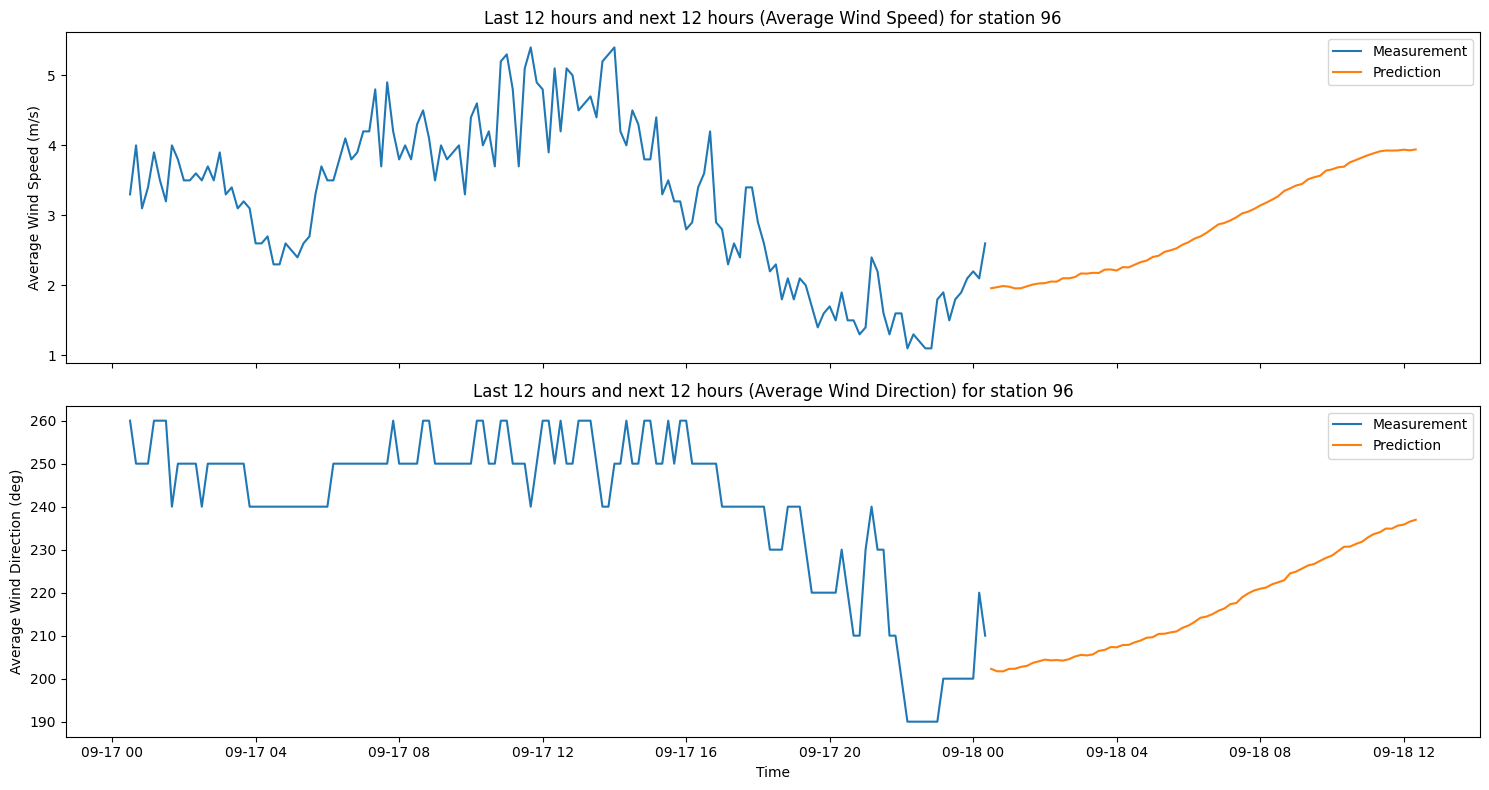

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Only use station_id = 96
station_id = STATION_ID

# Ensure record_date is datetime
test_df = df_36h_drop_last12.copy()
test_df["record_date"] = pd.to_datetime(test_df["record_date"])
preds = preds.copy()
preds["record_date"] = pd.to_datetime(preds["record_date"])

# Filter for station_id = 96
test_df_96 = test_df[test_df["station_id"] == station_id]
preds_96 = preds[preds["station_id"] == station_id]

# Find the last timestamp in test_df_96
last_test_time = test_df_96["record_date"].max()
# Get the last 12 hours of measurements (10-min interval: 72 steps)
twelve_hours_ago = last_test_time - pd.Timedelta(hours=24)
test_last12 = test_df_96[test_df_96["record_date"] > twelve_hours_ago].sort_values("record_date")

# For preds, get the predictions for station_id = 96, and for the 12 hours after last_test_time
preds_12h = preds_96[preds_96["record_date"] > last_test_time].sort_values("record_date").head(72)

# Concatenate for plotting: measurement columns are 'average_wind_speed', 'average_wind_direction'
# prediction columns are 'average_wind_speed_pred', 'average_wind_direction_pred'
plot_df = pd.DataFrame({
    "record_date": pd.concat([test_last12["record_date"], preds_12h["record_date"]]),
    "average_wind_speed": pd.concat([test_last12["average_wind_speed"], preds_12h["average_wind_speed_pred"]]),
    "average_wind_direction": pd.concat([test_last12["average_wind_direction"], preds_12h["average_wind_direction_pred"]]),
    "type": ["measurement"] * len(test_last12) + ["prediction"] * len(preds_12h)
})

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot average wind speed
for t, g in plot_df.groupby("type"):
    axs[0].plot(g["record_date"], g["average_wind_speed"], label=t.capitalize())
axs[0].set_ylabel("Average Wind Speed (m/s)")
axs[0].legend()
axs[0].set_title(f"Last 12 hours and next 12 hours (Average Wind Speed) for station {station_id}")

# Plot average wind direction
for t, g in plot_df.groupby("type"):
    axs[1].plot(g["record_date"], g["average_wind_direction"], label=t.capitalize())
axs[1].set_ylabel("Average Wind Direction (deg)")
axs[1].legend()
axs[1].set_title(f"Last 12 hours and next 12 hours (Average Wind Direction) for station {station_id}")

axs[1].set_xlabel("Time")
plt.tight_layout()
plt.show()


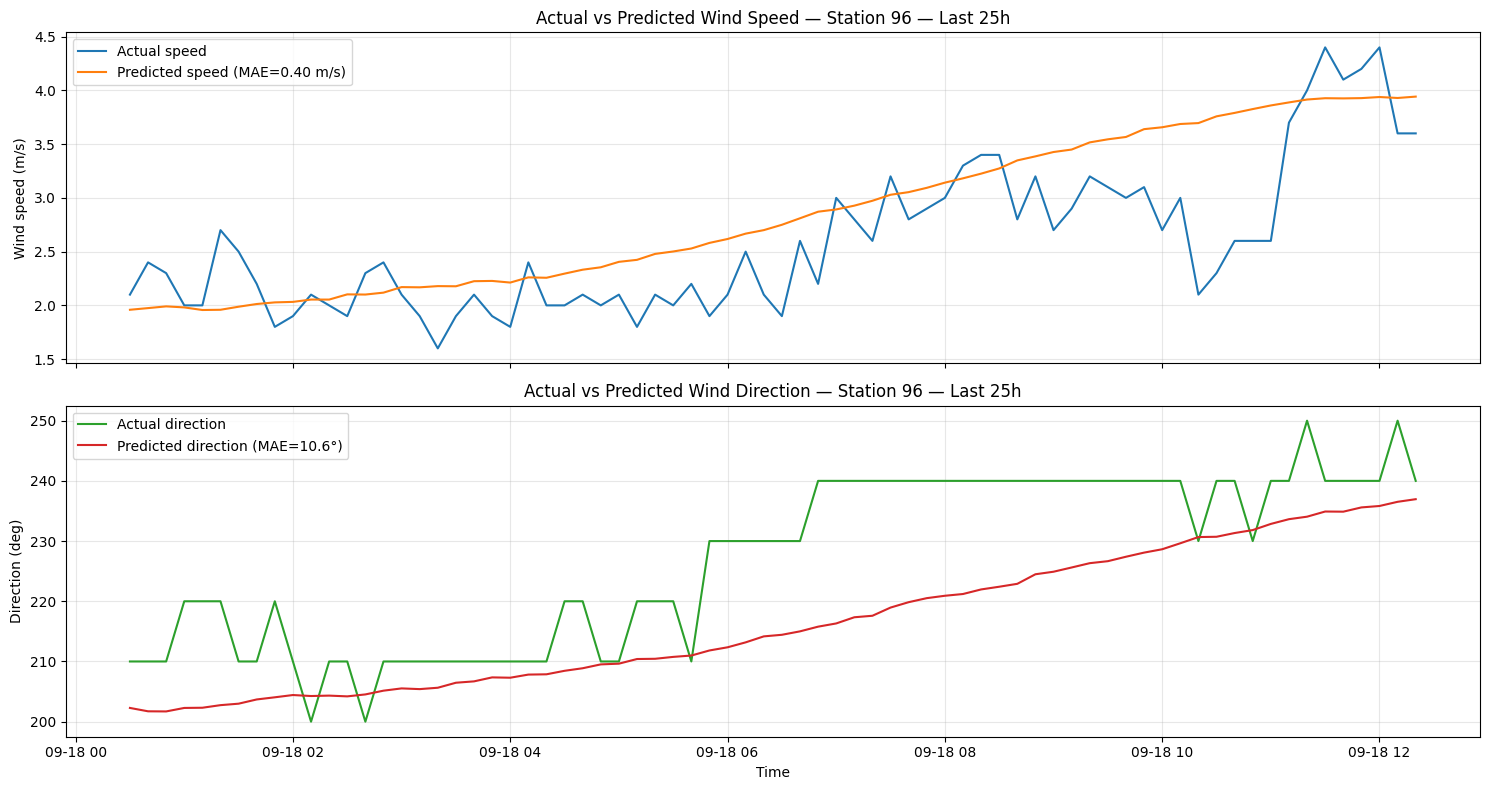

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Overlay predictions vs real measurements at the same timestamps
# - Requires variables: test_df (real), preds (predictions) with columns listed below
# Columns expected:
#   test_df: ['station_id', 'record_date', 'average_wind_speed', 'average_wind_direction']
#   preds:   ['station_id', 'record_date', 'average_wind_speed_pred', 'average_wind_direction_pred']

# Choose station and time window (hours)
station_id = STATION_ID
hours_window = 25

# Defensive copies and dtype fixes
_real = df_36h.copy()
_pred = preds.copy()
_real["record_date"] = pd.to_datetime(_real["record_date"])  # ensure datetime
_pred["record_date"] = pd.to_datetime(_pred["record_date"])  # ensure datetime

# Keep only necessary columns
_real = _real[["station_id", "record_date", "average_wind_speed", "average_wind_direction"]]
_pred = _pred[["station_id", "record_date", "average_wind_speed_pred", "average_wind_direction_pred"]]

# If there are duplicate predictions per timestamp, keep the last (or you could average)
_pred = (_pred
    .sort_values(["station_id", "record_date"]) 
    .drop_duplicates(subset=["station_id", "record_date"], keep="last")
)

# Inner-join on the same timestamp so we compare like-for-like
merged = pd.merge(
    _real, _pred,
    on=["station_id", "record_date"],
    how="inner"
)

# Focus on one station
merged = merged[merged["station_id"] == station_id].sort_values("record_date")

if merged.empty:
    print(f"No overlapping timestamps between real and predicted for station {station_id}.")
else:
    # Filter to last N hours
    end_time = merged["record_date"].max()
    start_time = end_time - pd.Timedelta(hours=hours_window)
    plot_df = merged[(merged["record_date"] >= start_time) & (merged["record_date"] <= end_time)]

    # Metrics for the selection
    mae_speed = (plot_df["average_wind_speed_pred"] - plot_df["average_wind_speed"]).abs().mean()
    # Direction error (degrees) using minimal circular difference
    ang_diff = (plot_df["average_wind_direction_pred"] - plot_df["average_wind_direction"]) % 360.0
    ang_diff = np.where(ang_diff > 180.0, 360.0 - ang_diff, ang_diff)
    mae_dir = np.mean(np.abs(ang_diff))

    fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # Speed overlay
    axs[0].plot(plot_df["record_date"], plot_df["average_wind_speed"], label="Actual speed", color="tab:blue")
    axs[0].plot(plot_df["record_date"], plot_df["average_wind_speed_pred"], label=f"Predicted speed (MAE={mae_speed:.2f} m/s)", color="tab:orange")
    axs[0].set_ylabel("Wind speed (m/s)")
    axs[0].set_title(f"Actual vs Predicted Wind Speed — Station {station_id} — Last {hours_window}h")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Direction overlay
    axs[1].plot(plot_df["record_date"], plot_df["average_wind_direction"], label="Actual direction", color="tab:green")
    axs[1].plot(plot_df["record_date"], plot_df["average_wind_direction_pred"], label=f"Predicted direction (MAE={mae_dir:.1f}°)", color="tab:red")
    axs[1].set_ylabel("Direction (deg)")
    axs[1].set_title(f"Actual vs Predicted Wind Direction — Station {station_id} — Last {hours_window}h")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    axs[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


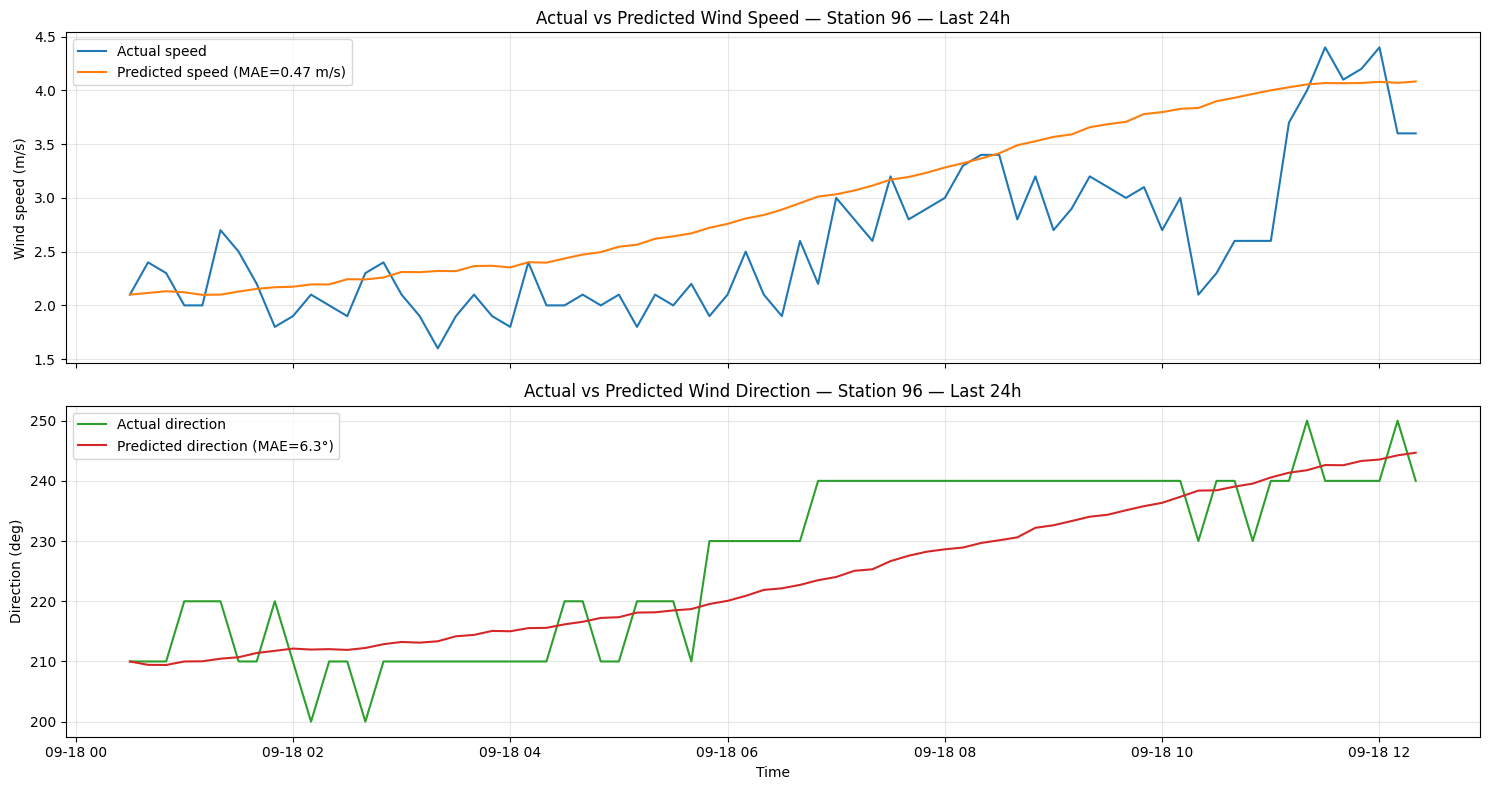

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Overlay predictions vs real measurements at the same timestamps
# - Requires variables: test_df (real), preds (predictions) with columns listed below
# Columns expected:
#   test_df: ['station_id', 'record_date', 'average_wind_speed', 'average_wind_direction']
#   preds:   ['station_id', 'record_date', 'average_wind_speed_pred', 'average_wind_direction_pred']

# Choose station and time window (hours)
station_id = STATION_ID
hours_window = 24

# Defensive copies and dtype fixes
_real = df_36h.copy()
_pred = preds.copy()
_real["record_date"] = pd.to_datetime(_real["record_date"])  # ensure datetime
_pred["record_date"] = pd.to_datetime(_pred["record_date"])  # ensure datetime

# Keep only necessary columns
_real = _real[["station_id", "record_date", "average_wind_speed", "average_wind_direction"]]
_pred = _pred[["station_id", "record_date", "average_wind_speed_pred", "average_wind_direction_pred"]]

# If there are duplicate predictions per timestamp, keep the last (or you could average)
_pred = (_pred
    .sort_values(["station_id", "record_date"]) 
    .drop_duplicates(subset=["station_id", "record_date"], keep="last")
)

# Inner-join on the same timestamp so we compare like-for-like
merged = pd.merge(
    _real, _pred,
    on=["station_id", "record_date"],
    how="inner"
)

# Focus on one station
merged = merged[merged["station_id"] == station_id].sort_values("record_date")

if merged.empty:
    print(f"No overlapping timestamps between real and predicted for station {station_id}.")
else:
    # Filter to last N hours
    end_time = merged["record_date"].max()
    start_time = end_time - pd.Timedelta(hours=hours_window)
    plot_df = merged[(merged["record_date"] >= start_time) & (merged["record_date"] <= end_time)].copy()

    # --- Adjustment: Move first pred value to actual value, adjust all preds by the same diff ---
    if not plot_df.empty:
        # For wind speed
        first_real_speed = plot_df.iloc[0]["average_wind_speed"]
        first_pred_speed = plot_df.iloc[0]["average_wind_speed_pred"]
        diff_speed = first_real_speed - first_pred_speed
        plot_df["average_wind_speed_pred"] = plot_df["average_wind_speed_pred"] + diff_speed

        # For wind direction (circular, so use minimal angle diff)
        first_real_dir = plot_df.iloc[0]["average_wind_direction"]
        first_pred_dir = plot_df.iloc[0]["average_wind_direction_pred"]
        # Calculate minimal signed angle difference
        diff_dir = (first_real_dir - first_pred_dir + 180) % 360 - 180
        plot_df["average_wind_direction_pred"] = (plot_df["average_wind_direction_pred"] + diff_dir) % 360

    # Metrics for the selection
    mae_speed = (plot_df["average_wind_speed_pred"] - plot_df["average_wind_speed"]).abs().mean()
    # Direction error (degrees) using minimal circular difference
    ang_diff = (plot_df["average_wind_direction_pred"] - plot_df["average_wind_direction"]) % 360.0
    ang_diff = np.where(ang_diff > 180.0, 360.0 - ang_diff, ang_diff)
    mae_dir = np.mean(np.abs(ang_diff))

    fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # Speed overlay
    axs[0].plot(plot_df["record_date"], plot_df["average_wind_speed"], label="Actual speed", color="tab:blue")
    axs[0].plot(plot_df["record_date"], plot_df["average_wind_speed_pred"], label=f"Predicted speed (MAE={mae_speed:.2f} m/s)", color="tab:orange")
    axs[0].set_ylabel("Wind speed (m/s)")
    axs[0].set_title(f"Actual vs Predicted Wind Speed — Station {station_id} — Last {hours_window}h")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Direction overlay
    axs[1].plot(plot_df["record_date"], plot_df["average_wind_direction"], label="Actual direction", color="tab:green")
    axs[1].plot(plot_df["record_date"], plot_df["average_wind_direction_pred"], label=f"Predicted direction (MAE={mae_dir:.1f}°)", color="tab:red")
    axs[1].set_ylabel("Direction (deg)")
    axs[1].set_title(f"Actual vs Predicted Wind Direction — Station {station_id} — Last {hours_window}h")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    axs[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()
